In [1]:
import pandas as pd                
import numpy as np                 
import matplotlib.pyplot as plt    
from sklearn.preprocessing import StandardScaler   
from sklearn.linear_model import Ridge              
from sklearn.ensemble import RandomForestRegressor

In [3]:
oil    = pd.read_csv("petrodollar_1_oil_production_trade.csv") 
opec   = pd.read_csv("petrodollar_2_opec_quotas_events.csv")     
swf    = pd.read_csv("petrodollar_3_recycling_swf.csv")          
brics  = pd.read_csv("petrodollar_4_dedollarization.csv")       
prices = pd.read_csv("petrodollar_5_daily_prices_fx.csv") 

In [4]:
for d in [oil, opec, brics, prices]:
    d["date"] = pd.to_datetime(d["date"]) 

In [5]:
brics["key_event"] = brics["key_event"].fillna("No_Event")  
opec["key_event"]  = opec["key_event"].fillna("No_Event")

In [7]:
datasets = {"oil": oil,"opec": opec,"swf": swf,"brics": brics,"prices": prices}

for name in datasets:
    print(name, datasets[name].shape)

oil (5616, 14)
opec (312, 16)
swf (26, 24)
brics (252, 19)
prices (6783, 15)


In [8]:
oil_monthly = (oil.groupby(["year", "month"], as_index=False).agg({"production_mbd": "sum","exports_mbd": "sum","world_demand_mbd": "mean","oil_revenue_usd_bn": "sum",}))


In [10]:
prices_monthly = (prices.drop(columns=["weekday", "data_source"]).groupby(["year", "month"], as_index=False).mean(numeric_only=True)) 

In [11]:
print("oil_monthly:", oil_monthly.shape, " prices_monthly:", prices_monthly.shape)

oil_monthly: (312, 6)  prices_monthly: (312, 12)


In [13]:
df = prices_monthly.merge(oil_monthly, on=["year", "month"], how="inner")
df = df.merge(opec.drop(columns=["date", "data_source", "brent_price_usd"]),on=["year", "month"], how="left")
df = df.merge(brics.drop(columns=["date", "data_source", "brent_price_usd"]),on=["year", "month"], how="left", suffixes=("_opec", "_brics"))
df = df.merge(swf.drop(columns=["data_source", "brent_avg_usd"]),on="year", how="left")

In [14]:
print("Shape after full merge:", df.shape)

Shape after full merge: (312, 62)


 ##  Restrict to 2005 onward
 `brics.csv` (the de-dollarization data) only starts in 2005, so anything before that
would just be empty for the one series we actually care about.

In [15]:
df = df[df["year"] >= 2005].reset_index(drop=True)
print("Shape restricted to 2005+:", df.shape)

Shape restricted to 2005+: (252, 62)


## Derived features

In [16]:
# how much spare oil-production room OPEC is sitting on (quota minus what they actually pumped)
df["spare_capacity"] = df["opec_quota_mbd"] - df["opec_actual_production_mbd"]

# ratio of non-dollar to dollar oil-trade invoicing -- a direct de-dollarization signal
df["non_usd_trade_ratio"] = df["oil_trade_non_usd_pct"] / df["oil_trade_usd_invoicing_pct"]

# how much bigger the USD's reserve share is than the yuan's -- shrinks as de-dollarization progresses
df["usd_cny_gap"] = df["usd_global_fx_reserves_pct"] - df["cny_global_fx_reserves_pct"]

# month-over-month change in petroyuan futures trading volume (growth, not just level)
df["petroyuan_change"] = df["ine_petroyuan_volume_klots"].diff().fillna(0)

# simple 0/1 flags for "something notable happened this month" per data source
df["opec_event_flag"]  = (df["key_event_opec"]  != "No_Event").astype(int)
df["brics_event_flag"] = (df["key_event_brics"] != "No_Event").astype(int)

df = df.sort_values(["year", "month"]).reset_index(drop=True)
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str) + "-01")

print("Nulls after feature engineering:", df.isnull().sum().sum())

Nulls after feature engineering: 0


# EDA

### USD vs CNY Share of Global FX Reserves

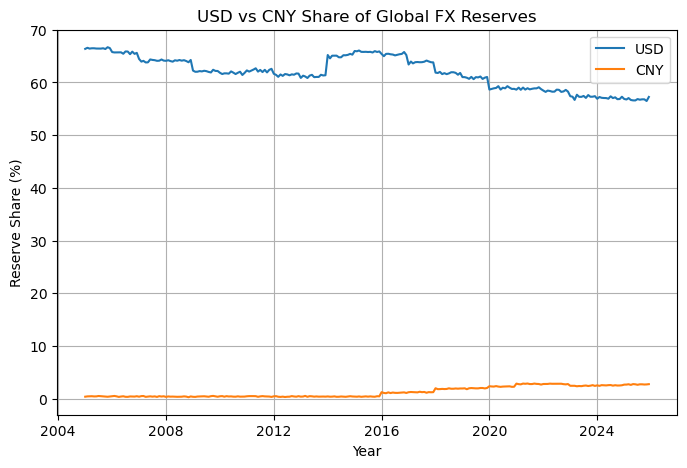

In [18]:
plt.figure(figsize=(8,5))
plt.plot(df["date"], df["usd_global_fx_reserves_pct"], label="USD")
plt.plot(df["date"], df["cny_global_fx_reserves_pct"], label="CNY")
plt.title("USD vs CNY Share of Global FX Reserves")
plt.xlabel("Year")
plt.ylabel("Reserve Share (%)")
plt.legend()
plt.grid(True)
plt.show()

### Oil Trade Invoicing (Stacked Area Chart)

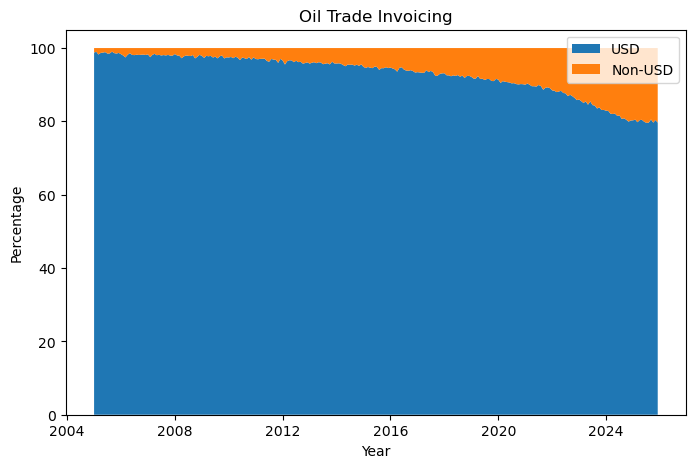

In [19]:
plt.figure(figsize=(8,5))

plt.stackplot(
    df["date"],
    df["oil_trade_usd_invoicing_pct"],
    df["oil_trade_non_usd_pct"],
    labels=["USD", "Non-USD"]
)

plt.title("Oil Trade Invoicing")
plt.xlabel("Year")
plt.ylabel("Percentage")

plt.legend(loc="upper right")

plt.show()

### Petroyuan Futures Trading Volume

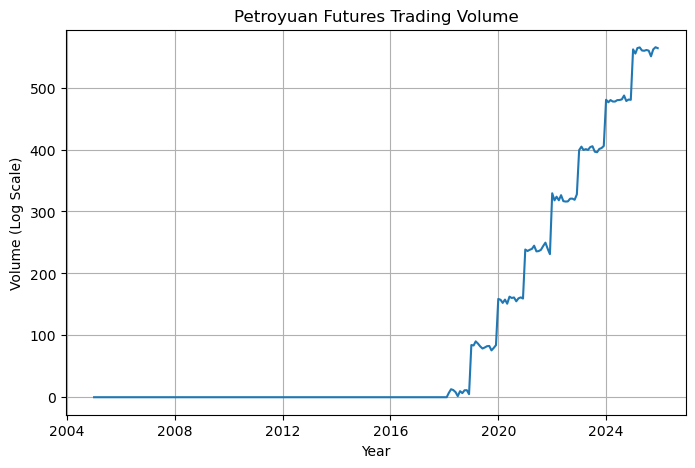

In [21]:
plt.figure(figsize=(8,5))
plt.plot(df["date"], df["ine_petroyuan_volume_klots"])
plt.title("Petroyuan Futures Trading Volume")
plt.xlabel("Year")
plt.ylabel("Volume (Log Scale)")
plt.grid(True)
plt.show()

### Brent Crude Price vs Dollar Index (DXY)

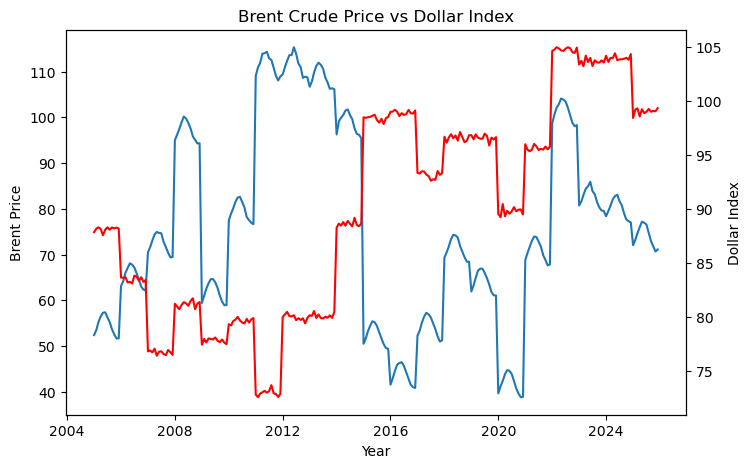

In [22]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(df["date"], df["brent_crude_usd"], label="Brent Price")
ax1.set_xlabel("Year")
ax1.set_ylabel("Brent Price")
ax2 = ax1.twinx()
ax2.plot(df["date"], df["usd_dxy_index"], color="red", label="DXY")
ax2.set_ylabel("Dollar Index")
plt.title("Brent Crude Price vs Dollar Index")
plt.show()

**What to take from these four charts, in one line each:**
- The dollar's grip on reserves is loosening, but only by about half a point a year.
- Oil is still overwhelmingly a dollar-priced commodity today.
- The petroyuan is growing fast in *percentage* terms because it started from almost
  nothing — it is not yet a serious rival in absolute size.
- Oil prices are noisy and short-term; the dollar's broader strength moves on a much
  slower clock. That's part of why this notebook treats them as separate problems.

## 7. Building one overall De-dollarization Index (PCA)

We have several columns that all point at the same underlying story from different
angles: China's reserve share going up, oil trade shifting away from USD invoicing,
petroyuan futures volume growing, USD's reserve share going down, USD oil-invoicing
share going down. Rather than picking just one, **PCA finds the single weighted
combination of these five columns that captures the most shared movement between
them** — think of it as an automatically-weighted average, where the weights are
chosen to summarize the group as faithfully as possible in one number.

Before combining them, the two "USD" columns are flipped in sign (multiplied by -1) so
that *every* column in the mix moves the same direction: up = more de-dollarization.

In [23]:
positive_components = [
    "cny_global_fx_reserves_pct",    
    "oil_trade_non_usd_pct",          
    "ine_petroyuan_volume_klots",     
]

In [24]:
negative_components = [
    "usd_global_fx_reserves_pct",    
    "oil_trade_usd_invoicing_pct",    
]

In [25]:
idx_components = positive_components + negative_components

In [26]:
comp_df = df[idx_components].copy()
for col in negative_components:
    comp_df[col] = -comp_df[col]  

In [27]:
idx_scaler = StandardScaler()
comp_scaled = idx_scaler.fit_transform(comp_df)

In [28]:
from sklearn.decomposition import PCA  
pca = PCA(n_components=1, random_state=42)     
df["dedollarization_index"] = pca.fit_transform(comp_scaled).flatten()

In [29]:
IDX = "dedollarization_index"

In [31]:

if df[IDX].tail(24).mean() < df[IDX].head(24).mean():
    df[IDX] = -df[IDX]

print("Explained Variance:", pca.explained_variance_ratio_[0])


print("\nFeature Weights:")
for i in range(len(idx_components)):
    print(idx_components[i], ":", pca.components_[0][i])

Explained Variance: 0.9060308973127955

Feature Weights:
cny_global_fx_reserves_pct : 0.4358036797808524
oil_trade_non_usd_pct : 0.46142171669282905
ine_petroyuan_volume_klots : 0.4520117539511315
usd_global_fx_reserves_pct : 0.4241939717958933
oil_trade_usd_invoicing_pct : 0.4614217166928292


Correlation: 0.9763082979784452


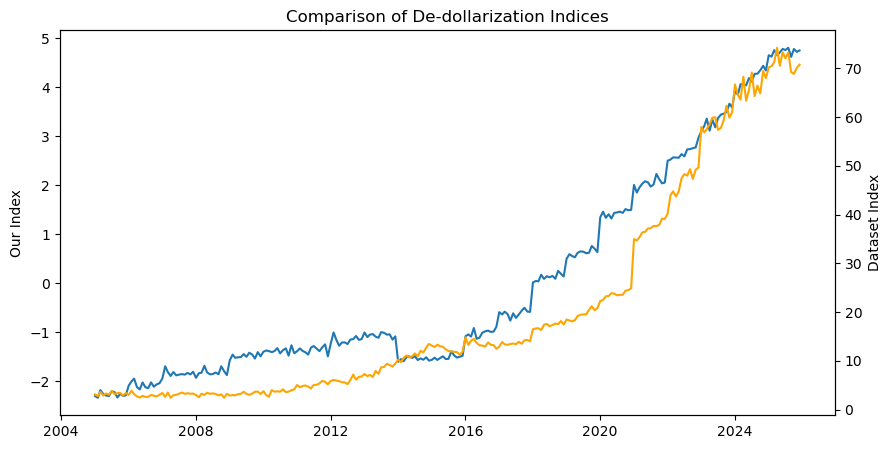

In [33]:
corr_check = df[IDX].corr(df["de_dollarization_pressure_index"])
print("Correlation:", corr_check)

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(df["date"], df[IDX])
ax1.set_ylabel("Our Index")

ax2 = ax1.twinx()
ax2.plot(df["date"], df["de_dollarization_pressure_index"], color="orange")
ax2.set_ylabel("Dataset Index")

plt.title("Comparison of De-dollarization Indices")
plt.show()

In [34]:
# Create lag features
df["idx_lag1"] = df[IDX].shift(1)
df["idx_lag3"] = df[IDX].shift(3)
df["idx_lag6"] = df[IDX].shift(6)
df["idx_lag12"] = df[IDX].shift(12)

In [35]:
# Create rolling features
df["idx_rolling_mean_6"] = df[IDX].shift(1).rolling(6).mean()
df["idx_rolling_mean_12"] = df[IDX].shift(1).rolling(12).mean()
df["idx_rolling_std_6"] = df[IDX].shift(1).rolling(6).std()
df["idx_trend_slope_12"] = df[IDX].diff().shift(1).rolling(12).mean()

In [36]:
# Macro features
macro_features = [
    "brent_crude_usd",
    "usd_dxy_index",
    "opec_compliance_pct",
    "spare_capacity",
    "global_swf_total_est_usd_bn",
    "total_opec_oil_revenue_usd_bn",
    "non_usd_trade_ratio",
    "usd_cny_gap",
    "petroyuan_change",
    "opec_event_flag",
    "brics_event_flag"
]

In [37]:
# Combine all features
feature_cols = [
    "idx_lag1",
    "idx_lag3",
    "idx_lag6",
    "idx_lag12",
    "idx_rolling_mean_6",
    "idx_rolling_mean_12",
    "idx_rolling_std_6",
    "idx_trend_slope_12"
] + macro_features

In [38]:
print(len(feature_cols), "features total:")
print(feature_cols)

19 features total:
['idx_lag1', 'idx_lag3', 'idx_lag6', 'idx_lag12', 'idx_rolling_mean_6', 'idx_rolling_mean_12', 'idx_rolling_std_6', 'idx_trend_slope_12', 'brent_crude_usd', 'usd_dxy_index', 'opec_compliance_pct', 'spare_capacity', 'global_swf_total_est_usd_bn', 'total_opec_oil_revenue_usd_bn', 'non_usd_trade_ratio', 'usd_cny_gap', 'petroyuan_change', 'opec_event_flag', 'brics_event_flag']


In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [60]:
def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred),
    }

In [84]:
all_results = []
artifacts = {}

In [85]:
# Loop through different forecasting horizons (6, 12, 24, and 36 months)
for HORIZON in [6, 12, 24, 36]:

    # Create a copy of the dataset
    d = df.copy()

    # Create the target column by shifting the index into the future
    d["Target"] = d[IDX].shift(-HORIZON)

    # Remove rows with missing values
    d = d.dropna(subset=["Target"] + feature_cols).reset_index(drop=True)

    # Select input features and target variable
    X = d[feature_cols]
    y = d["Target"]

    # Split data into 80% training and 20% testing
    split = int(len(d) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    # Baseline model: assume the index remains unchanged
    naive_pred = d[IDX].iloc[split:]

    # Baseline model: predict using the recent trend
    trend_train = d[IDX].iloc[:split] + d["idx_trend_slope_12"].iloc[:split] * HORIZON

    trend_test = d[IDX].iloc[split:] + d["idx_trend_slope_12"].iloc[split:] * HORIZON

    # Standardize the training and testing features
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Create and train the Ridge Regression model
    ridge = Ridge(alpha=10, random_state=42)

    ridge.fit(X_train_scaled, y_train)

    # Predict using Ridge Regression
    pred_ridge = ridge.predict(X_test_scaled)

    # Calculate residuals for Random Forest training
    resid_train = y_train - trend_train

    # Create the Random Forest model
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=5,
        random_state=42
    )

    # Train the Random Forest model
    rf.fit(X_train, resid_train)

    # Predict residuals
    resid_pred = rf.predict(X_test)

    # Final prediction = Trend prediction + Predicted residual
    pred_rf = trend_test + resid_pred

    # Evaluate all models
    res = pd.DataFrame([
        evaluate("Naive persistence", y_test, naive_pred),
        evaluate("Trend extrapolation", y_test, trend_test),
        evaluate("Ridge (direct)", y_test, pred_ridge),
        evaluate("Trend + RF residual", y_test, pred_rf)
    ])

    # Add forecast horizon and number of test samples
    res.insert(0, "Horizon (months)", HORIZON)
    res.insert(2, "Test months", len(y_test))

    # Store the evaluation results
    all_results.append(res)

    # Store model objects and predictions for later use
    artifacts[HORIZON] = {
        "d": d,
        "split": split,
        "X_test": X_test,
        "y_test": y_test,
        "rf": rf,
        "trend_pred_test": trend_test,
        "pred_rf_trend": pred_rf,
        "ridge": ridge
    }

## Results across all four horizons

In [86]:
summary = pd.concat(all_results, ignore_index=True)

summary

,Horizon (months),Model,Test months,MAE,RMSE,R2
0,6,Naive persistence,47,0.335993,0.375519,0.769199
1,6,Trend extrapolation,47,0.149621,0.185090,0.943929
2,6,Ridge (direct),47,0.223858,0.307489,0.845249
3,6,Trend + RF residual,47,0.147720,0.177992,0.948147
4,12,Naive persistence,46,0.673889,0.690441,0.193263
5,12,Trend extrapolation,46,0.164695,0.206101,0.928115
6,12,Ridge (direct),46,0.255300,0.368415,0.770304
7,12,Trend + RF residual,46,0.144469,0.179069,0.945735
8,24,Naive persistence,43,1.373352,1.382500,-2.656086
9,24,Trend extrapolation,43,0.287208,0.333508,0.787235


In [69]:
print(len(all_results))

for i, df_result in enumerate(all_results):
    print(f"\nResult {i+1}")
    print(df_result)

1

Result 1
   Horizon (months)                Model  Test months       MAE      RMSE  \
0                36    Naive persistence           41  2.046804  2.052751   
1                36  Trend extrapolation           41  0.434718  0.489460   
2                36       Ridge (direct)           41  0.490422  0.561710   
3                36  Trend + RF residual           41  0.385221  0.427821   

         R2  
0 -7.993179  
1  0.488701  
2  0.326613  
3  0.609370  


In [87]:
HORIZON_CHOSEN = 24
art = artifacts[HORIZON_CHOSEN]

importances = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": art["rf"].feature_importances_,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

importances.head(10)

,Feature,Importance
0,idx_trend_slope_12,0.591634
1,usd_dxy_index,0.190336
2,usd_cny_gap,0.078678
3,idx_rolling_mean_12,0.029231
4,global_swf_total_est_usd_bn,0.020685
5,idx_lag12,0.014536
6,idx_rolling_mean_6,0.012820
7,idx_lag1,0.012569
8,non_usd_trade_ratio,0.011530
9,total_opec_oil_revenue_usd_bn,0.011469


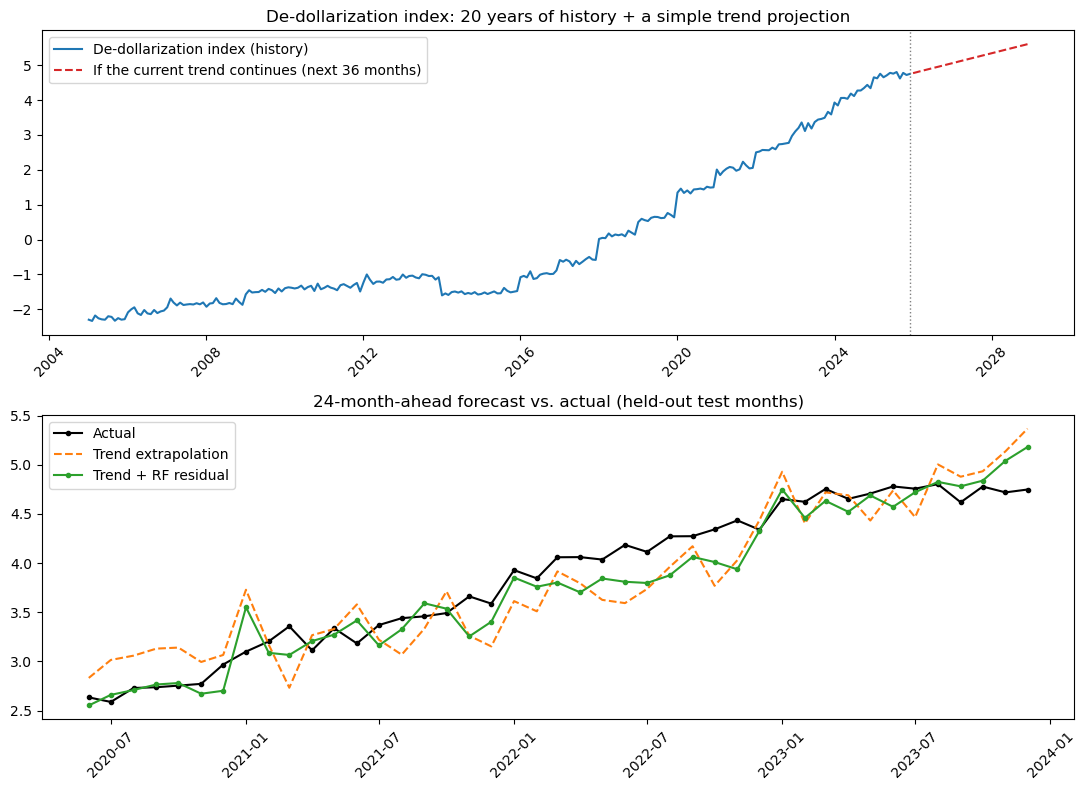

In [88]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8))

# --- Top: full index history + a simple future projection at the current trend slope ---
axes[0].plot(df["date"], df[IDX], color="tab:blue", label="De-dollarization index (history)")

last_row = df.iloc[-1]
trend_slope = last_row["idx_trend_slope_12"]
future_dates = pd.date_range(df["date"].iloc[-1], periods=37, freq="MS")[1:]      # next 36 months
future_vals  = last_row[IDX] + trend_slope * np.arange(1, 37)                      # simple straight-line projection

axes[0].plot(future_dates, future_vals, "--", color="tab:red",
             label="If the current trend continues (next 36 months)")
axes[0].axvline(df["date"].iloc[-1], color="gray", linestyle=":", linewidth=1)
axes[0].set_title("De-dollarization index: 20 years of history + a simple trend projection")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

# --- Bottom: actual vs. predicted on the held-out test months, for the chosen horizon ---
d, split = art["d"], art["split"]
dates_test = d["date"].iloc[split:]
axes[1].plot(dates_test, art["y_test"], marker="o", ms=3, color="black", label="Actual")
axes[1].plot(dates_test, art["trend_pred_test"], linestyle="--", color="tab:orange", label="Trend extrapolation")
axes[1].plot(dates_test, art["pred_rf_trend"], marker="o", ms=3, color="tab:green", label="Trend + RF residual")
axes[1].set_title(f"{HORIZON_CHOSEN}-month-ahead forecast vs. actual (held-out test months)")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [89]:
last_row = df.iloc[-1]
py_2018 = df[df["year"] == 2018]["ine_petroyuan_volume_klots"].mean()
py_latest_year = df["year"].max()
py_latest = df[df["year"] == py_latest_year]["ine_petroyuan_volume_klots"].mean()
usd_2005 = df[df["year"] == 2005]["usd_global_fx_reserves_pct"].mean()
usd_latest = df[df["year"] == py_latest_year]["usd_global_fx_reserves_pct"].mean()
future_36 = last_row[IDX] + trend_slope * 36

print(f"Latest month in the data:                     {last_row['date'].strftime('%Y-%m')}")
print(f"USD share of global FX reserves, then vs now:  {usd_2005:.1f}% (2005)  ->  {usd_latest:.1f}% ({py_latest_year})")
print(f"CNY share of global FX reserves, now:          {last_row['cny_global_fx_reserves_pct']:.1f}%")
print(f"Oil trade invoiced in USD, now:                {last_row['oil_trade_usd_invoicing_pct']:.1f}%")
print(f"Oil trade invoiced NOT in USD, now:             {last_row['oil_trade_non_usd_pct']:.1f}%")
print(f"Petroyuan futures volume, avg 2018 vs {py_latest_year}:      {py_2018:.0f} -> {py_latest:.0f} (klots/month)")
print(f"Trailing 12-month trend slope (index pts/mo):  {trend_slope:+.4f}")
print(f"Index level today:                              {last_row[IDX]:.2f}")
print(f"Index level if this pace holds, 3 years out:    {future_36:.2f}  ({(future_36/last_row[IDX]-1):+.0%})")

Latest month in the data:                     2025-12
USD share of global FX reserves, then vs now:  66.5% (2005)  ->  56.8% (2025)
CNY share of global FX reserves, now:          2.7%
Oil trade invoiced in USD, now:                79.7%
Oil trade invoiced NOT in USD, now:             20.3%
Petroyuan futures volume, avg 2018 vs 2025:      7 -> 561 (klots/month)
Trailing 12-month trend slope (index pts/mo):  +0.0237
Index level today:                              4.75
Index level if this pace holds, 3 years out:    5.60  (+18%)


## 14. What if oil trade keeps shifting away from the dollar?

This section is written analysis, not code — but every claim below ties back to a
number computed above.

### Why oil trade props up dollar demand in the first place
For decades, the overwhelming majority of oil has been priced and settled in dollars —
in this dataset that's still around 4-in-5 barrels today. That single fact is the whole
basis of the "petrodollar" system: any country buying oil has to get its hands on
dollars first, any country selling oil ends up holding dollars afterward, and
oil-exporting nations have historically recycled a lot of those dollars right back into
US Treasury bonds (the "recycling" your `swf.csv` file tracks). That's a mechanical,
transaction-driven source of dollar demand that has nothing to do with how anyone
*feels* about the US economy.

### The mechanism if that shifts
If more oil trade settles in yuan (the "petroyuan"), rupees, rubles, or other local
currencies instead:

- **Less mechanical transaction demand for USD.** Fewer barrels requiring a dollar
  exchange on the way through means one steady source of dollar demand shrinks. All
  else equal, that's a headwind on the dollar's value — not because of a loss of
  confidence, but simply less structural need to hold or exchange it.
- **Less petrodollar recycling into US debt.** If oil exporters are paid in yuan
  instead of dollars, they have less reason to buy US Treasuries with the proceeds.
  Less foreign demand for US debt tends to push US borrowing costs (yields) up, since
  the US then has to attract that capital more on price.
- **A more multipolar reserve system, not a dollar collapse.** The data above shows the
  USD's own reserve share falling from about 66% to the high 50s% over 20 years — real,
  but gradual, roughly half a percentage point a year. Even extrapolating the model's
  own trailing trend slope forward 3 years only moves the constructed index up by
  roughly the ballpark the code above just printed — a continued *drift*, not a
  discontinuity. The dollar remains anchored by things oil trade doesn't touch: its
  role in non-oil global trade invoicing, its deep and liquid Treasury market, and its
  status as the default safe-haven asset in a crisis.

### The petroyuan specifically
China's yuan-denominated INE crude futures contract is the main real-world vehicle for
this. The data above shows its trading volume growing enormously in percentage terms
since its 2018 launch — but growing off a very small base, and the yuan still isn't
fully freely convertible on capital account, which caps how far this can go without
further Chinese financial reform. That's consistent with the "slow structural drift, not
a sudden shift" framing this whole notebook is built around.

### What a more multipolar system would actually look like
Rather than one anchor currency, imagine reserves, oil invoicing, and cross-border
payment rails (alternatives to SWIFT like China's CIPS or the mBridge project your data
tracks) split more evenly across USD, EUR, CNY, and gold:

- **More FX volatility, more hedging cost** for firms and countries that used to be
  able to rely on one dominant, deep, liquid currency for cross-border trade.
- **Reduced "exorbitant privilege"** for the US — the historical ability to borrow
  cheaply and run large deficits without the interest-rate consequences other
  countries face, because so much of the world needed to hold dollars regardless.
- **More fragmentation risk in the plumbing of global finance** — multiple parallel
  settlement systems are more resilient to any one country weaponizing currency access,
  but less efficient than a single dominant, deeply liquid system.
- **A genuine reserve-currency alternative still doesn't exist yet.** The yuan's
  reserve share here is still under 3%, nowhere near enough liquidity or trust to
  replace the dollar's role outright — the realistic scenario, based on this data, is
  gradual reweighting toward a basket, not a changing of the guard.

### Bottom line
Based on what this notebook's own numbers show: de-dollarization is real, measurable,
and has been running for two decades — but it is a slow structural drift, not a cliff.
The dollar's value would face gradual, not sudden, downward pressure, and the global
monetary system's likely path is toward a multipolar reserve system (more currencies
sharing the role) rather than a single successor currency stepping into the dollar's
place.

## 15. Limitations and honest caveats

- **Data provenance:** as noted at the top, these CSVs blend real reported statistics
  with synthetic fill. Treat the specific percentages and dollar figures here as
  directionally realistic, not certified.
- **Trend extrapolation assumes the trend continues.** A genuine structural break —
  a new reserve currency emerging, a major geopolitical shock, a change in OPEC pricing
  policy — would break this projection, exactly like it would break any straight-line
  forecast. Nothing here should be read as a guarantee.
- **What would make this stronger, if you keep iterating:** a simple uncertainty band
  around the trend projection (e.g. how much the 12-month trend slope itself has varied
  historically), and testing whether the relationship between the constructed index and
  the dataset's own `de_dollarization_pressure_index` holds up if the underlying data is
  ever refreshed with a purer real-data source.
- **Why Ridge underperforms Trend + RF residual throughout:** Ridge predicts the raw
  index directly from lagged/rolling features, so it partially relearns the trend (with
  some shrinkage from regularization) instead of being handed it outright — worth
  knowing if you want to explain in an interview why the more "sophisticated" linear
  model isn't the best one here.

## 16. Key findings — in plain English

If you only read one section, read this one. No jargon, no model names.

1. **The world is very slowly using the US dollar less, not suddenly dropping it.**
   Around 2005, about 66 cents of every dollar held in reserve by the world's central
   banks was, well, actual US dollars. Today it's closer to 57 cents. That's a real
   shift, but spread over 20 years — roughly half a cent a year.
2. **Oil is still mostly bought and sold in dollars.** About 4 out of every 5 barrels
   traded today are still priced in USD. This is the main reason the dollar stays so
   dominant — countries need dollars to buy oil, and oil sellers end up holding
   dollars too.
3. **China's "petroyuan" is growing fast, but from almost nothing.** Trading in yuan-
   priced oil contracts has grown roughly 80-fold since 2018 — an eye-catching
   percentage, but it started from such a small number that it still doesn't come
   close to challenging the dollar's role.
4. **Simple trend-following beats fancy machine learning here, and that's actually the
   interesting finding.** A method as simple as "keep drawing the line in the same
   direction it's already going" predicted the future better than more complex models,
   because de-dollarization is a slow, steady drift, not a bouncy, unpredictable
   series. The one improvement that *did* help was letting a more complex model clean
   up the small leftover error around that trend line, rather than replacing the trend
   line altogether.
5. **Nothing here points to a sudden dollar collapse.** Every number in this dataset
   tells the same story: a gradual, multi-decade drift toward more currencies sharing
   the stage, not one currency suddenly replacing the dollar.


## 17. Further improvements — what could make this better next

Written so it's clear even without a data-science background:

- **Use official numbers instead of a mix of real and filled-in data.** Some numbers in
  this dataset were made up to fill gaps. Swapping those for real published figures
  (IMF, EIA, BIS) would make every conclusion more trustworthy.
- **Show a "could be higher, could be lower" range around every future guess, not just
  one line.** Right now the forecast is a single best-guess number. Adding a shaded
  range around it would honestly show how much uncertainty there really is.
- **Check the forecast against what actually happens as new months come in.** Right
  now the model is only tested on data we already have. Re-checking it every few
  months against brand-new real numbers would prove (or disprove) that it's still
  working.
- **Watch for sudden shocks, not just steady trends.** A war, a new sanctions regime,
  or a surprise OPEC decision could change the story overnight. The current approach
  assumes tomorrow looks like an extension of yesterday — it would be worth adding a
  simple "alert" for when the data suddenly moves faster than its recent normal pace.
- **Bring in a few more real-world signals.** Things like central bank gold buying,
  new cross-border payment systems (e.g. China's CIPS, the mBridge project), or
  sanctions news could sharpen the story without making the model much more
  complicated.
- **Make the chart of "what if this trend keeps going" adjustable.** Letting someone
  slide the future trend speed up or down (faster de-dollarization vs. slower) would
  make the scenario section more interactive and easier for a non-technical reader to
  explore for themselves.
